# HighRes-Net Inference Diagnostics (HR-Expected)

Use this notebook when each input sample has both:
- 7 LR views (LR_*.tif/tiff)
- 1 HR counterpart (HR.tif/tiff)

This notebook focuses on:
- Low-VRAM tiled 2x inference (8 GB-friendly)
- Single-sample visual inspection
- HR-based metrics (PSNR, SSIM, RMSE, LPIPS)
- Optional multi-image benchmark and CSV report

## 1. Setup and Imports

In [84]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import ndimage
import lpips

# Add src directory to path
sys.path.insert(0, '../src')

import torch
from torch.utils.data import DataLoader

from DataLoader import TiffPatchDataset, collateFunction
from DeepNetworks.HRNet import HRNet
from diagnostics import (
    check_model_weights,
    compute_metrics,
 )

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# LPIPS (perceptual similarity) for SR trend monitoring
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lpips_fn = lpips.LPIPS(net='alex').to(device)
lpips_fn.eval()
print(f"LPIPS metric initialized on {device}")

PyTorch Version: 2.7.1+cu118
CUDA Available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Memory: 8.59 GB
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


d:\GUC\HighResNet model\HighRes-net\hr_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\GUC\HighResNet model\HighRes-net\hr_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: d:\GUC\HighResNet model\HighRes-net\hr_env\Lib\site-packages\lpips\weights\v0.1\alex.pth
LPIPS metric initialized on cuda


## 2. Quick Diagnostic: Check Image Loading First

In [85]:
# Verify TIFF dataset structure (new format, not old PNG format)
dataset_root = Path("D:\\GUC\\Datasets\\HighRes input test")
image_dirs = sorted([d for d in dataset_root.iterdir() if d.is_dir() and d.name.startswith('image_')])

print("\n" + "="*70)
print("DATASET VERIFICATION (TIFF Format)")
print("="*70)
print(f"\nDataset root: {dataset_root}")
print(f"Found {len(image_dirs)} image folders")

diag_results = {}

if len(image_dirs) > 0:
    diag_results['num_images'] = len(image_dirs)
    print(f"✓ Image folders: {[d.name for d in image_dirs[:5]]}{'...' if len(image_dirs) > 5 else ''}")
    
    # Check first image folder
    first_image = image_dirs[0]
    print(f"\nChecking first folder: {first_image.name}")
    
    lr_files = sorted(first_image.glob("LR_*.*"))
    hr_files = sorted(first_image.glob("HR.*"))
    
    print(f"  LR frames found: {len(lr_files)}")
    print(f"  HR files found: {len(hr_files)}")
    
    if len(lr_files) > 0 and len(hr_files) > 0:
        print(f"  ✓ Structure looks good (LR frames + HR present)")
        diag_results['structure_valid'] = True
        
        # Get file extensions
        lr_ext = lr_files[0].suffix
        hr_ext = hr_files[0].suffix
        print(f"  File types: LR{lr_ext}, HR{hr_ext}")
    else:
        print(f"  ✗ Missing LR frames or HR file!")
        diag_results['structure_valid'] = False
else:
    print(f"✗ No image_* folders found!")
    diag_results['num_images'] = 0

print("="*70)


DATASET VERIFICATION (TIFF Format)

Dataset root: D:\GUC\Datasets\HighRes input test
Found 1 image folders
✓ Image folders: ['image_11111']

Checking first folder: image_11111
  LR frames found: 7
  HR files found: 1
  ✓ Structure looks good (LR frames + HR present)
  File types: LR.tiff, HR.tiff


## 3. Check Model Weights Status

In [86]:
# Check if model has trained weights
weight_status = check_model_weights(Path("../models/weights/HRNet.pth"))

if not weight_status.get('has_weights', False):
    print("\n" + "="*70)
    print("⚠️ CRITICAL: Model is using RANDOM weights")
    print("="*70)
    print("""
This explains why your SR output looks bad:
- Grainy/noisy (random noise from uninitialized weights)
- Darker than expected (random negative scales)
- Artifacts/scan lines (random filter patterns)

NEXT STEPS:
1. Train the model on your data
2. Or find pre-trained weights for your domain
3. Or use bicubic upsampling for baseline comparison
    """)


Model Weight Status Check
Looking for: ..\models\weights\HRNet.pth

✓ Weights file found!
  File size: 2.4 MB
  Parameters in checkpoint: 31 layers


## 4. Load Configuration

In [87]:
config_path = '../config/config.json'
with open(config_path, 'r') as f:
    config = json.load(f)

print("Configuration:")
print(f"  n_views: {config['training']['n_views']}")
print(f"  min_L: {config['training']['min_L']}")
print(f"  batch_size: {config['training']['batch_size']}")
print(f"  Upsampling stride: {config['network']['decoder']['deconv']['stride']}x")
print(f"  Lambda range: {config['training'].get('lambda_range', 'Not set')}")

# Note: Scale validation happens during actual data loading below, 
# not from the diagnostic diag_results

Configuration:
  n_views: 7
  min_L: 7
  batch_size: 8
  Upsampling stride: 2x
  Lambda range: 0.003


## 5. Load Model Architecture

In [88]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = HRNet(config['network'])
model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model total parameters: {total_params:,}")
print(f"Model is in EVAL mode (no batch norm, no dropout)")

Using device: cuda
Model total parameters: 620,490
Model is in EVAL mode (no batch norm, no dropout)


## 6. Load Pre-trained Weights

In [89]:
weights_path = Path("../models/weights/HRNet.pth")

if weights_path.exists():
    print(f"Loading weights from {weights_path}")
    try:
        state_dict = torch.load(str(weights_path), map_location=device)
        model.load_state_dict(state_dict)
        print("✓ Weights loaded successfully!")
    except Exception as e:
        print(f"✗ Failed to load weights: {e}")
        print(f"  Using random initialization (output will be low quality)")
else:
    print(f"✗ Weights file not found at {weights_path}")
    print(f"  Using RANDOM initialization")
    print(f"  Expected output quality: POOR (grainy, noisy, artifacts)")

Loading weights from ..\models\weights\HRNet.pth
✓ Weights loaded successfully!


## 7. Create Dataset and DataLoader

In [90]:
dataset_root = Path("D:\\GUC\\Datasets\\HighRes input test")
image_dirs = sorted([d for d in dataset_root.iterdir() if d.is_dir() and d.name.startswith('image_')])

print(f"Found {len(image_dirs)} images")
if len(image_dirs) > 0:
    print(f"Images: {[d.name for d in image_dirs[:5]]}...")

# Convert to strings
image_dirs_str = [str(d) for d in image_dirs]

# Create dataset
dataset = TiffPatchDataset(
    patch_dirs=image_dirs_str,
    max_views=config['training']['n_views']
)

print(f"Dataset size: {len(dataset)} images")

# Create dataloader
min_L = config['training']['min_L']
inference_batch_size = 1  # Critical for full-chip inference on 8 GB VRAM

dataloader = DataLoader(
    dataset,
    batch_size=inference_batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=collateFunction(min_L=min_L),
    pin_memory=torch.cuda.is_available()
)

print(f"DataLoader created with batch_size={inference_batch_size}")

Found 1 images
Images: ['image_11111']...
Dataset size: 1 images
DataLoader created with batch_size=1


## 8. Run Inference on First Batch

In [91]:
batch = next(iter(dataloader))
lrs, alphas, hrs, hr_maps, names = batch

print(f"Batch loaded:")
print(f"  LR shape: {lrs.shape}")
print(f"  Alphas shape: {alphas.shape}")
print(f"  HR shape: {hrs.shape}")
print(f"  HR_map shape: {hr_maps.shape}")
print(f"  Image names: {names}")

# Keep tensors on CPU here. Move only small tiles to GPU in the next cell.
lrs = lrs.float().cpu()
alphas = alphas.float().cpu()

print("\nData kept on CPU for tiled low-VRAM inference")

Batch loaded:
  LR shape: torch.Size([1, 7, 520, 520])
  Alphas shape: torch.Size([1, 7])
  HR shape: torch.Size([1, 1, 520, 520])
  HR_map shape: torch.Size([1, 520, 520])
  Image names: ['image_11111']

Data kept on CPU for tiled low-VRAM inference


## 9. Tiled Forward Pass (Single Safe 8 GB Profile)

**IMPORTANT:** Run all cells in order from top to bottom. Each cell depends on variables from previous cells.
If you get `NameError`, restart the kernel and re-run from the beginning without skipping cells.

In [92]:
# Single default profile chosen for stable 8 GB VRAM inference
inference_cfg = {
    'tile_size': 160,
    'halo': 96,
    'use_amp': False,
}
print(f"Default low-VRAM inference config: {inference_cfg}")

# Optional advanced override (uncomment only if needed):
# inference_cfg.update({'tile_size': 192, 'halo': 80, 'use_amp': False})


def tiled_forward_hrnet(model, lrs_cpu, alphas_cpu, device, tile_size=192, halo=96, use_amp=False):
    """
    Memory-safe tiled HRNet inference with fixed central-crop stitching.

    Key properties for artifact-safe stitching:
    - Pads input to tile grid first (reflect).
    - Uses fixed-size tiles with fixed halo context.
    - Uses fixed central crop from each SR tile (no interpolation/resizing).
    - Keeps accumulation deterministic in output coordinates.

    Inputs:
      lrs_cpu:    [B, V, H, W] on CPU
      alphas_cpu: [B, V] on CPU
    Returns:
      [B, 1, H_out, W_out] on CPU
    """
    model.eval()
    outputs = []

    with torch.no_grad():
        B, _, H, W = lrs_cpu.shape
        step = int(tile_size)
        hctx = int(halo)
        amp_enabled = bool(use_amp and device.type == 'cuda')

        # Infer integer scale once from a small probe
        probe_h = min(64, H)
        probe_w = min(64, W)
        probe_lr = lrs_cpu[:1, :, :probe_h, :probe_w].to(device, non_blocking=True)
        probe_alpha = alphas_cpu[:1].to(device, non_blocking=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=amp_enabled):
            probe_sr = model(probe_lr, probe_alpha)[:, 0]
        sy = max(1, int(round(probe_sr.shape[-2] / probe_h)))
        sx = max(1, int(round(probe_sr.shape[-1] / probe_w)))
        del probe_lr, probe_alpha, probe_sr

        for b in range(B):
            sample = lrs_cpu[b:b+1]
            alpha = alphas_cpu[b:b+1]

            # Pad sample to full tile grid so every placed patch has same target size
            Hp = ((H + step - 1) // step) * step
            Wp = ((W + step - 1) // step) * step
            pad_bottom = Hp - H
            pad_right = Wp - W

            # Reflect pad to avoid edge artifacts from zero padding
            sample_grid = torch.nn.functional.pad(sample, (0, pad_right, 0, pad_bottom), mode='reflect')

            # Add global halo so each extracted tile has fixed (step + 2*halo) size
            sample_ext = torch.nn.functional.pad(sample_grid, (hctx, hctx, hctx, hctx), mode='reflect')

            out_hp = Hp * sy
            out_wp = Wp * sx
            sr_acc = torch.zeros((1, out_hp, out_wp), dtype=torch.float32)
            sr_wgt = torch.zeros((1, out_hp, out_wp), dtype=torch.float32)

            for y0 in range(0, Hp, step):
                for x0 in range(0, Wp, step):
                    # Fixed-size LR tile including halo context
                    y_ext0 = y0
                    y_ext1 = y0 + step + 2 * hctx
                    x_ext0 = x0
                    x_ext1 = x0 + step + 2 * hctx

                    lr_tile = sample_ext[:, :, y_ext0:y_ext1, x_ext0:x_ext1].to(device, non_blocking=True)
                    alpha_tile = alpha.to(device, non_blocking=True)

                    with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=amp_enabled):
                        sr_tile = model(lr_tile, alpha_tile)[:, 0]  # [1, Ht, Wt]

                    sr_tile = sr_tile.float().cpu()

                    # Fixed central crop corresponding to the non-halo LR area
                    cy0 = hctx * sy
                    cy1 = cy0 + step * sy
                    cx0 = hctx * sx
                    cx1 = cx0 + step * sx
                    crop = sr_tile[:, cy0:cy1, cx0:cx1]

                    ty0 = y0 * sy
                    ty1 = ty0 + step * sy
                    tx0 = x0 * sx
                    tx1 = tx0 + step * sx

                    sr_acc[:, ty0:ty1, tx0:tx1] += crop
                    sr_wgt[:, ty0:ty1, tx0:tx1] += 1.0

                    del lr_tile, alpha_tile, sr_tile, crop

            # Normalize and crop padded output back to original scene size
            sr_grid = sr_acc / sr_wgt.clamp_min(1.0)
            sr_out = sr_grid[:, : H * sy, : W * sx].unsqueeze(0)  # [1, 1, H_out, W_out]
            outputs.append(sr_out)

    return torch.cat(outputs, dim=0)

Default low-VRAM inference config: {'tile_size': 160, 'halo': 96, 'use_amp': False}


In [93]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    mem_before = torch.cuda.memory_allocated() / 1e9
    print(f"GPU memory before: {mem_before:.2f} GB")

try:
    sr_output = tiled_forward_hrnet(
        model=model,
        lrs_cpu=lrs,
        alphas_cpu=alphas,
        device=device,
        tile_size=inference_cfg['tile_size'],
        halo=inference_cfg['halo'],
        use_amp=inference_cfg['use_amp'],
    )
except torch.cuda.OutOfMemoryError:
    print("\n⚠️ CUDA OOM with current profile. Retrying with safer low-VRAM settings...")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    sr_output = tiled_forward_hrnet(
        model=model,
        lrs_cpu=lrs,
        alphas_cpu=alphas,
        device=device,
        tile_size=128,
        halo=96,
        use_amp=False,
    )

if torch.cuda.is_available():
    mem_after = torch.cuda.memory_allocated() / 1e9
    mem_peak = torch.cuda.max_memory_allocated() / 1e9
    print(f"GPU memory after: {mem_after:.2f} GB")
    print(f"Peak GPU memory: {mem_peak:.2f} GB")

print(f"\nSR output shape: {sr_output.shape}")
print(f"SR output dtype: {sr_output.dtype}")
print(f"SR value range: [{sr_output.min():.4f}, {sr_output.max():.4f}]")

GPU memory before: 0.02 GB
GPU memory after: 0.02 GB
Peak GPU memory: 1.14 GB

SR output shape: torch.Size([1, 1, 1040, 1040])
SR output dtype: torch.float32
SR value range: [0.1676, 0.9153]


## 10. Extract and Analyze First Sample

In [94]:
sr = sr_output[0, 0].cpu().numpy()
lr_first = lrs[0, 0].cpu().numpy()
hr_true = hrs[0].numpy() if torch.is_tensor(hrs) else hrs[0] if isinstance(hrs, list) else None

# Squeeze channel dimension if present
if hr_true is not None and hr_true.ndim == 3:
    hr_true = np.squeeze(hr_true, axis=0)

# Create upsampled LR for visual comparison
lr_upsampled = np.repeat(np.repeat(lr_first, 2, axis=0), 2, axis=1)
sr = np.clip(sr, 0, 1)

print(f"Extracted first sample:")
print(f"  LR: {lr_first.shape} → SR: {sr.shape} → HR: {hr_true.shape if hr_true is not None else 'Not loaded'}")

Extracted first sample:
  LR: (520, 520) → SR: (1040, 1040) → HR: (520, 520)


## 11. Compute Quality Metrics

In [95]:
from scipy import ndimage

print("\n" + "="*70)
print("Image Quality Metrics (SR vs Ground Truth)")
print("="*70)

if hr_true is not None:
    # Ensure hr_true is 2D
    if hr_true.ndim == 3:
        hr_true = np.squeeze(hr_true, axis=0)

    hr_map_true = None
    if 'hr_maps' in globals() and hr_maps is not None:
        hr_map_true = hr_maps[0].cpu().numpy() if torch.is_tensor(hr_maps) else hr_maps[0]

    # Resize HR to match SR if needed
    if hr_true.shape != sr.shape:
        scale = sr.shape[0] / hr_true.shape[0]
        hr_true = ndimage.zoom(hr_true, scale, order=3)
        if hr_map_true is not None:
            hr_map_true = ndimage.zoom(hr_map_true, scale, order=0)

    # Compute metrics for HighRes-Net
    nn_metrics = compute_metrics(hr_true, sr, hr_map=hr_map_true)
    if nn_metrics['valid']:
        print(f"\n🧠 HighRes-Net Output (RAW metrics):")
        print(f"  PSNR: {nn_metrics['psnr']:.2f} dB ({nn_metrics['psnr_label']})")
        print(f"  SSIM: {nn_metrics['ssim']:.4f} ({nn_metrics['ssim_label']})")
        print(f"  RMSE: {nn_metrics['rmse']:.5f}")
        print(f"  Edge ratio (SR/HR): {nn_metrics['edge_ratio']:.3f} (near 1 is ideal)")
        print(f"  Contrast ratio (SR/HR std): {nn_metrics['contrast_ratio']:.3f} (near 1 is ideal)")
        print(f"  Robust range ratio P99-P1: {nn_metrics['p01_p99_range_ratio']:.3f} (near 1 is ideal)")

        print(f"\n🔎 Brightness-corrected view (diagnostic only):")
        print(f"  Brightness bias (HR-SR): {nn_metrics['brightness_bias']:+.5f}")
        print(f"  PSNR (bias-corrected): {nn_metrics['psnr_bias_corrected']:.2f} dB")
        print(f"  SSIM (bias-corrected): {nn_metrics['ssim_bias_corrected']:.4f}")

        # Compute LPIPS
        try:
            sr_tensor = torch.from_numpy(sr).float().unsqueeze(0).unsqueeze(0).to(device)
            hr_tensor = torch.from_numpy(hr_true).float().unsqueeze(0).unsqueeze(0).to(device)

            # Normalize from [0, 1] to [-1, 1]
            sr_tensor = sr_tensor * 2 - 1
            hr_tensor = hr_tensor * 2 - 1

            with torch.no_grad():
                lpips_score = lpips_fn(sr_tensor, hr_tensor).item()

            if lpips_score < 0.1:
                lpips_label = "Excellent (< 0.1)"
            elif lpips_score < 0.15:
                lpips_label = "Very Good (0.1-0.15)"
            elif lpips_score < 0.20:
                lpips_label = "Good (0.15-0.20)"
            elif lpips_score < 0.30:
                lpips_label = "Acceptable (0.20-0.30)"
            else:
                lpips_label = "Poor (> 0.30)"

            print(f"\n  LPIPS: {lpips_score:.4f} ({lpips_label})")
            print("  Note: LPIPS is useful as a trend signal here, not a single source of truth.")
        except Exception as e:
            print(f"  ⚠️  LPIPS computation failed: {e}")
    else:
        print(f"Cannot compute metrics: {nn_metrics['reason']}")

    # Compute bicubic baseline
    lr_bicubic = ndimage.zoom(lr_first, 2, order=3)
    if lr_bicubic.shape != hr_true.shape:
        scale = hr_true.shape[0] / lr_bicubic.shape[0]
        lr_bicubic = ndimage.zoom(lr_bicubic, scale, order=3)

    bicubic_metrics = compute_metrics(hr_true, lr_bicubic, hr_map=hr_map_true)
    if bicubic_metrics['valid']:
        print(f"\n📊 Bicubic Baseline (RAW metrics):")
        print(f"  PSNR: {bicubic_metrics['psnr']:.2f} dB ({bicubic_metrics['psnr_label']})")
        print(f"  SSIM: {bicubic_metrics['ssim']:.4f} ({bicubic_metrics['ssim_label']})")
        print(f"  RMSE: {bicubic_metrics['rmse']:.5f}")
        print(f"  Edge ratio (Bicubic/HR): {bicubic_metrics['edge_ratio']:.3f}")
        print(f"  Contrast ratio (Bicubic/HR): {bicubic_metrics['contrast_ratio']:.3f}")

        # Compute LPIPS for bicubic
        try:
            lr_bicubic_tensor = torch.from_numpy(lr_bicubic).float().unsqueeze(0).unsqueeze(0).to(device)
            hr_tensor = torch.from_numpy(hr_true).float().unsqueeze(0).unsqueeze(0).to(device)

            lr_bicubic_tensor = lr_bicubic_tensor * 2 - 1
            hr_tensor = hr_tensor * 2 - 1

            with torch.no_grad():
                lpips_bicubic = lpips_fn(lr_bicubic_tensor, hr_tensor).item()

            if lpips_bicubic < 0.1:
                lpips_bicubic_label = "Excellent (< 0.1)"
            elif lpips_bicubic < 0.15:
                lpips_bicubic_label = "Very Good (0.1-0.15)"
            elif lpips_bicubic < 0.20:
                lpips_bicubic_label = "Good (0.15-0.20)"
            elif lpips_bicubic < 0.30:
                lpips_bicubic_label = "Acceptable (0.20-0.30)"
            else:
                lpips_bicubic_label = "Poor (> 0.30)"

            print(f"  LPIPS: {lpips_bicubic:.4f} ({lpips_bicubic_label})")
        except Exception as e:
            print(f"  ⚠️  LPIPS computation failed: {e}")

        if nn_metrics['valid']:
            psnr_diff = nn_metrics['psnr'] - bicubic_metrics['psnr']
            ssim_diff = nn_metrics['ssim'] - bicubic_metrics['ssim']
            edge_diff = nn_metrics['edge_ratio'] - bicubic_metrics['edge_ratio']
            print(f"\n📈 HRNet vs Bicubic (RAW): PSNR {psnr_diff:+.2f} dB, SSIM {ssim_diff:+.4f}, Edge ratio {edge_diff:+.3f}")
            print("  Better model should improve several metrics together, not PSNR alone.")
else:
    print("HR ground truth not available")

print("="*70)



Image Quality Metrics (SR vs Ground Truth)

🧠 HighRes-Net Output (RAW metrics):
  PSNR: 31.78 dB (Good (30-35 dB))
  SSIM: 0.8874 (Good (0.80-0.90))
  RMSE: 0.02575
  Edge ratio (SR/HR): 0.933 (near 1 is ideal)
  Contrast ratio (SR/HR std): 0.994 (near 1 is ideal)
  Robust range ratio P99-P1: 1.007 (near 1 is ideal)

🔎 Brightness-corrected view (diagnostic only):
  Brightness bias (HR-SR): +0.00746
  PSNR (bias-corrected): 32.16 dB
  SSIM (bias-corrected): 0.8875

  LPIPS: 0.0691 (Excellent (< 0.1))
  Note: LPIPS is useful as a trend signal here, not a single source of truth.

📊 Bicubic Baseline (RAW metrics):
  PSNR: 29.03 dB (Acceptable (25-30 dB))
  SSIM: 0.8424 (Good (0.80-0.90))
  RMSE: 0.03538
  Edge ratio (Bicubic/HR): 0.998
  Contrast ratio (Bicubic/HR): 1.000
  LPIPS: 0.0548 (Excellent (< 0.1))

📈 HRNet vs Bicubic (RAW): PSNR +2.76 dB, SSIM +0.0450, Edge ratio -0.065
  Better model should improve several metrics together, not PSNR alone.


In [96]:
print("\n" + "="*70)
print("OUTPUT RANGE ANALYSIS - Contrast and Dynamic Range Check")
print("="*70)

sr_batch_min = sr_output.min().item()
sr_batch_max = sr_output.max().item()
sr_batch_range = sr_batch_max - sr_batch_min

hrs_batch_min = hrs.min().item()
hrs_batch_max = hrs.max().item()
hrs_batch_range = hrs_batch_max - hrs_batch_min

print(f"\n📊 SR Output (from model):")
print(f"  Min: {sr_batch_min:.4f}, Max: {sr_batch_max:.4f}")
print(f"  Range: {sr_batch_range:.4f}")
print(f"  Mean: {sr_output.mean():.4f}, Std: {sr_output.std():.4f}")

print(f"\n📊 HR Ground Truth:")
print(f"  Min: {hrs_batch_min:.4f}, Max: {hrs_batch_max:.4f}")
print(f"  Range: {hrs_batch_range:.4f}")
print(f"  Mean: {hrs.mean():.4f}, Std: {hrs.std():.4f}")

print(f"\n🔍 ANALYSIS:")

if sr_batch_range < 0.3:
    print(f"  🔴 RANGE SEVERELY COMPRESSED: {sr_batch_range:.4f} < 0.3")
    print(f"     Likely effects: blur and flat contrast")
    print(f"     Check training objective and normalization consistency")
elif sr_batch_range < hrs_batch_range * 0.7:
    print(f"  🟠 RANGE COMPRESSED: {sr_batch_range:.4f} vs HR {hrs_batch_range:.4f}")
    print(f"     Output is less dynamic than ground truth (likely blurry)")
    print(f"     Check loss balance, data normalization, and training stability")
elif sr_batch_range > hrs_batch_range * 1.3:
    print(f"  🟠 RANGE TOO WIDE: {sr_batch_range:.4f} vs HR {hrs_batch_range:.4f}")
    print(f"     Network may be producing over-contrasty or noisy outputs")
    print(f"     Check for oversharpening or unstable optimization")
else:
    print(f"  ✓ RANGE GOOD: SR {sr_batch_range:.4f} matches HR {hrs_batch_range:.4f}")

# Check contrast ratio
sr_std = sr_output.std().item()
hrs_std = hrs.std().item()
std_ratio = sr_std / hrs_std if hrs_std > 0 else 0

print(f"\n📈 Contrast (std deviation):")
print(f"  SR/HR ratio: {std_ratio:.3f}")

if std_ratio < 0.7:
    print(f"  ⚠️  SR has LESS contrast than HR -> blur/flatness indicator")
elif std_ratio > 1.3:
    print(f"  ⚠️  SR has MORE contrast than HR -> noise/over-enhancement indicator")
else:
    print(f"  ✓ Contrast ratio looks good")

print("\nℹ️ Note: This notebook reports image behavior; objective terms are defined in train.py.")
print("="*70)



OUTPUT RANGE ANALYSIS - Contrast and Dynamic Range Check

📊 SR Output (from model):
  Min: 0.1676, Max: 0.9153
  Range: 0.7477
  Mean: 0.8085, Std: 0.1248

📊 HR Ground Truth:
  Min: 0.1843, Max: 0.9294
  Range: 0.7451
  Mean: 0.8160, Std: 0.1258

🔍 ANALYSIS:
  ✓ RANGE GOOD: SR 0.7477 matches HR 0.7451

📈 Contrast (std deviation):
  SR/HR ratio: 0.992
  ✓ Contrast ratio looks good

ℹ️ Note: This notebook reports image behavior; objective terms are defined in train.py.


In [ ]:
print("\n" + "="*70)
print("MULTI-IMAGE BENCHMARK (HRNet vs Bicubic)")
print("="*70)

import pandas as pd
from scipy import ndimage


def run_multi_image_benchmark(model, dataloader, device, lpips_fn, max_samples=250):
    rows = []
    model.eval()

    with torch.no_grad():
        processed = 0
        for batch_idx, batch in enumerate(dataloader):
            if processed >= max_samples:
                break

            lrs_b, alphas_b, hrs_b, hr_maps_b, names_b = batch

            # Keep large tensors on CPU, use tiled low-VRAM forward
            lrs_cpu = lrs_b.float().cpu()
            alphas_cpu = alphas_b.float().cpu()

            srs_b = tiled_forward_hrnet(
                model=model,
                lrs_cpu=lrs_cpu,
                alphas_cpu=alphas_cpu,
                device=device,
                tile_size=inference_cfg['tile_size'],
                halo=inference_cfg['halo'],
                use_amp=inference_cfg['use_amp'],
            )[:, 0].detach().cpu().numpy()

            lrs_np = lrs_cpu[:, 0].detach().cpu().numpy()
            hrs_np = hrs_b.detach().cpu().numpy() if torch.is_tensor(hrs_b) else np.asarray(hrs_b)
            hr_maps_np = hr_maps_b.detach().cpu().numpy() if torch.is_tensor(hr_maps_b) else np.asarray(hr_maps_b)

            batch_size_local = srs_b.shape[0]
            for i in range(batch_size_local):
                if processed >= max_samples:
                    break

                sr_i = np.clip(srs_b[i], 0, 1)
                hr_i = hrs_np[i]
                if hr_i.ndim == 3:
                    hr_i = np.squeeze(hr_i, axis=0)
                hr_i = np.clip(hr_i, 0, 1)

                map_i = hr_maps_np[i]

                if hr_i.shape != sr_i.shape:
                    scale = sr_i.shape[0] / hr_i.shape[0]
                    hr_i = ndimage.zoom(hr_i, scale, order=3)
                    map_i = ndimage.zoom(map_i, scale, order=0)

                lr_bicubic_i = ndimage.zoom(lrs_np[i], 2, order=3)
                if lr_bicubic_i.shape != hr_i.shape:
                    scale = hr_i.shape[0] / lr_bicubic_i.shape[0]
                    lr_bicubic_i = ndimage.zoom(lr_bicubic_i, scale, order=3)

                m_sr = compute_metrics(hr_i, sr_i, hr_map=map_i)
                m_bc = compute_metrics(hr_i, lr_bicubic_i, hr_map=map_i)

                lpips_sr = np.nan
                lpips_bc = np.nan
                try:
                    sr_t = torch.from_numpy(sr_i).float().unsqueeze(0).unsqueeze(0).to(device)
                    hr_t = torch.from_numpy(hr_i).float().unsqueeze(0).unsqueeze(0).to(device)
                    bc_t = torch.from_numpy(lr_bicubic_i).float().unsqueeze(0).unsqueeze(0).to(device)

                    sr_t = sr_t * 2 - 1
                    hr_t = hr_t * 2 - 1
                    bc_t = bc_t * 2 - 1

                    lpips_sr = float(lpips_fn(sr_t, hr_t).item())
                    lpips_bc = float(lpips_fn(bc_t, hr_t).item())
                except Exception:
                    pass

                rows.append({
                    'name': names_b[i] if isinstance(names_b, list) else f'image_{processed}',
                    'psnr_sr': m_sr.get('psnr', np.nan),
                    'ssim_sr': m_sr.get('ssim', np.nan),
                    'rmse_sr': m_sr.get('rmse', np.nan),
                    'edge_ratio_sr': m_sr.get('edge_ratio', np.nan),
                    'contrast_ratio_sr': m_sr.get('contrast_ratio', np.nan),
                    'lpips_sr': lpips_sr,
                    'psnr_bicubic': m_bc.get('psnr', np.nan),
                    'ssim_bicubic': m_bc.get('ssim', np.nan),
                    'rmse_bicubic': m_bc.get('rmse', np.nan),
                    'edge_ratio_bicubic': m_bc.get('edge_ratio', np.nan),
                    'contrast_ratio_bicubic': m_bc.get('contrast_ratio', np.nan),
                    'lpips_bicubic': lpips_bc,
                    'delta_psnr': m_sr.get('psnr', np.nan) - m_bc.get('psnr', np.nan),
                    'delta_ssim': m_sr.get('ssim', np.nan) - m_bc.get('ssim', np.nan),
                    'delta_rmse': m_sr.get('rmse', np.nan) - m_bc.get('rmse', np.nan),
                    'delta_lpips': lpips_sr - lpips_bc,
                })
                processed += 1

    df = pd.DataFrame(rows)
    if len(df) == 0:
        print("No samples were evaluated.")
        return None

    summary = {
        'samples': len(df),
        'mean_delta_psnr': df['delta_psnr'].mean(),
        'mean_delta_ssim': df['delta_ssim'].mean(),
        'mean_delta_rmse': df['delta_rmse'].mean(),
        'mean_delta_lpips': df['delta_lpips'].mean(),
        'hrnet_wins_psnr': int((df['delta_psnr'] > 0).sum()),
        'hrnet_wins_ssim': int((df['delta_ssim'] > 0).sum()),
        'hrnet_wins_lpips': int((df['delta_lpips'] < 0).sum()),
    }

    return df, pd.Series(summary)


benchmark_result = run_multi_image_benchmark(
    model=model,
    dataloader=dataloader,
    device=device,
    lpips_fn=lpips_fn,
    max_samples=250
)

if benchmark_result is not None:
    benchmark_df, benchmark_summary = benchmark_result
    print("\nSummary:")
    print(benchmark_summary)

    print("\nTop 10 by PSNR gain over bicubic:")
    display(benchmark_df.sort_values('delta_psnr', ascending=False).head(10))

    print("\nMedian deltas (robust overview):")
    display(benchmark_df[['delta_psnr', 'delta_ssim', 'delta_rmse', 'delta_lpips']].median().to_frame('median'))

    benchmark_csv = Path("../models/weights/checkpoints/benchmark_last_run.csv")
    benchmark_csv.parent.mkdir(parents=True, exist_ok=True)
    benchmark_df.to_csv(benchmark_csv, index=False)
    print(f"\nSaved detailed benchmark table to: {benchmark_csv}")

print("="*70)



MULTI-IMAGE BENCHMARK (HRNet vs Bicubic)


## 12. Visualize Comparison

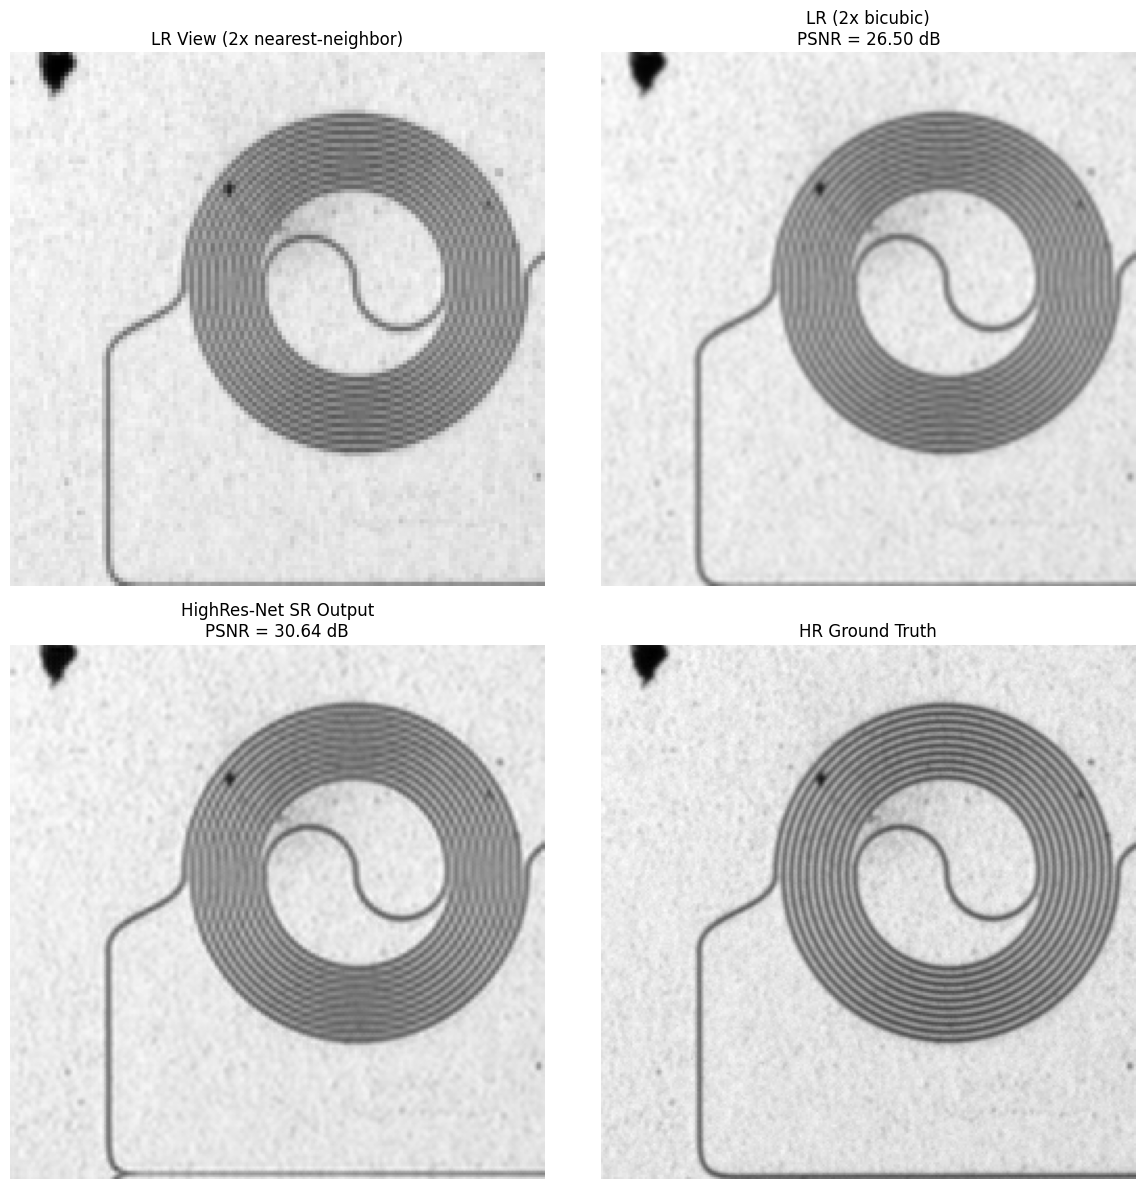

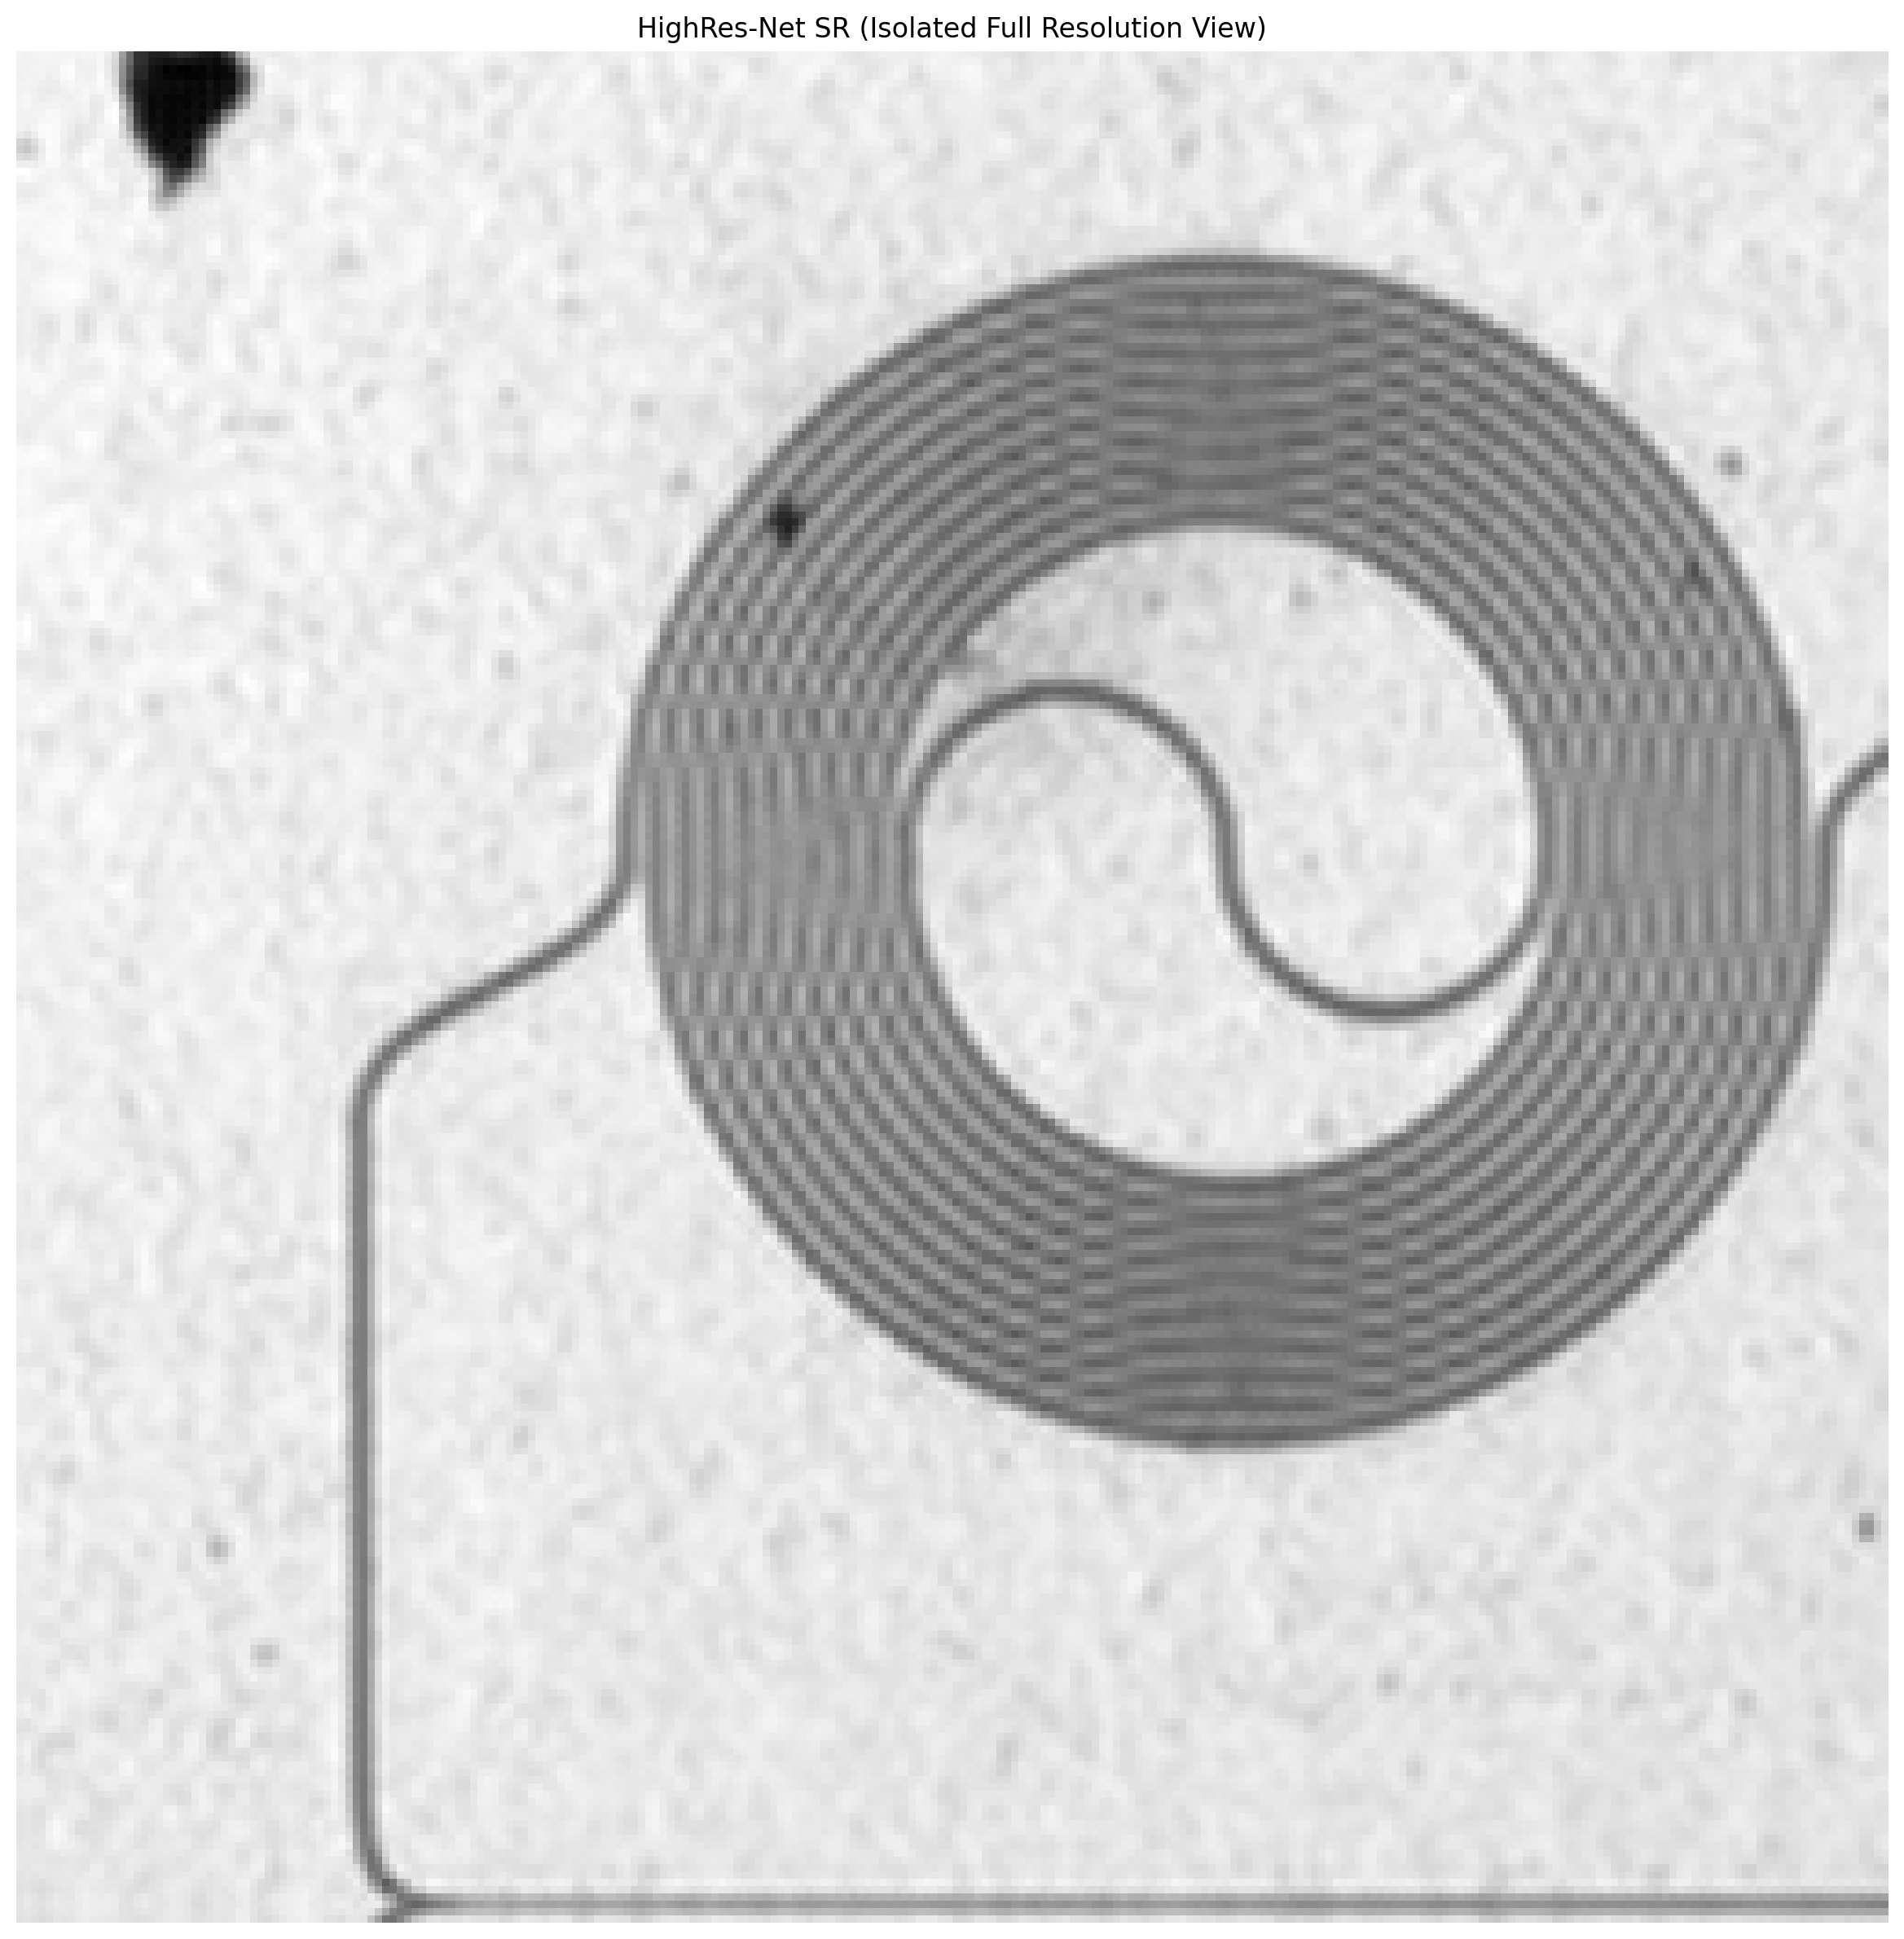

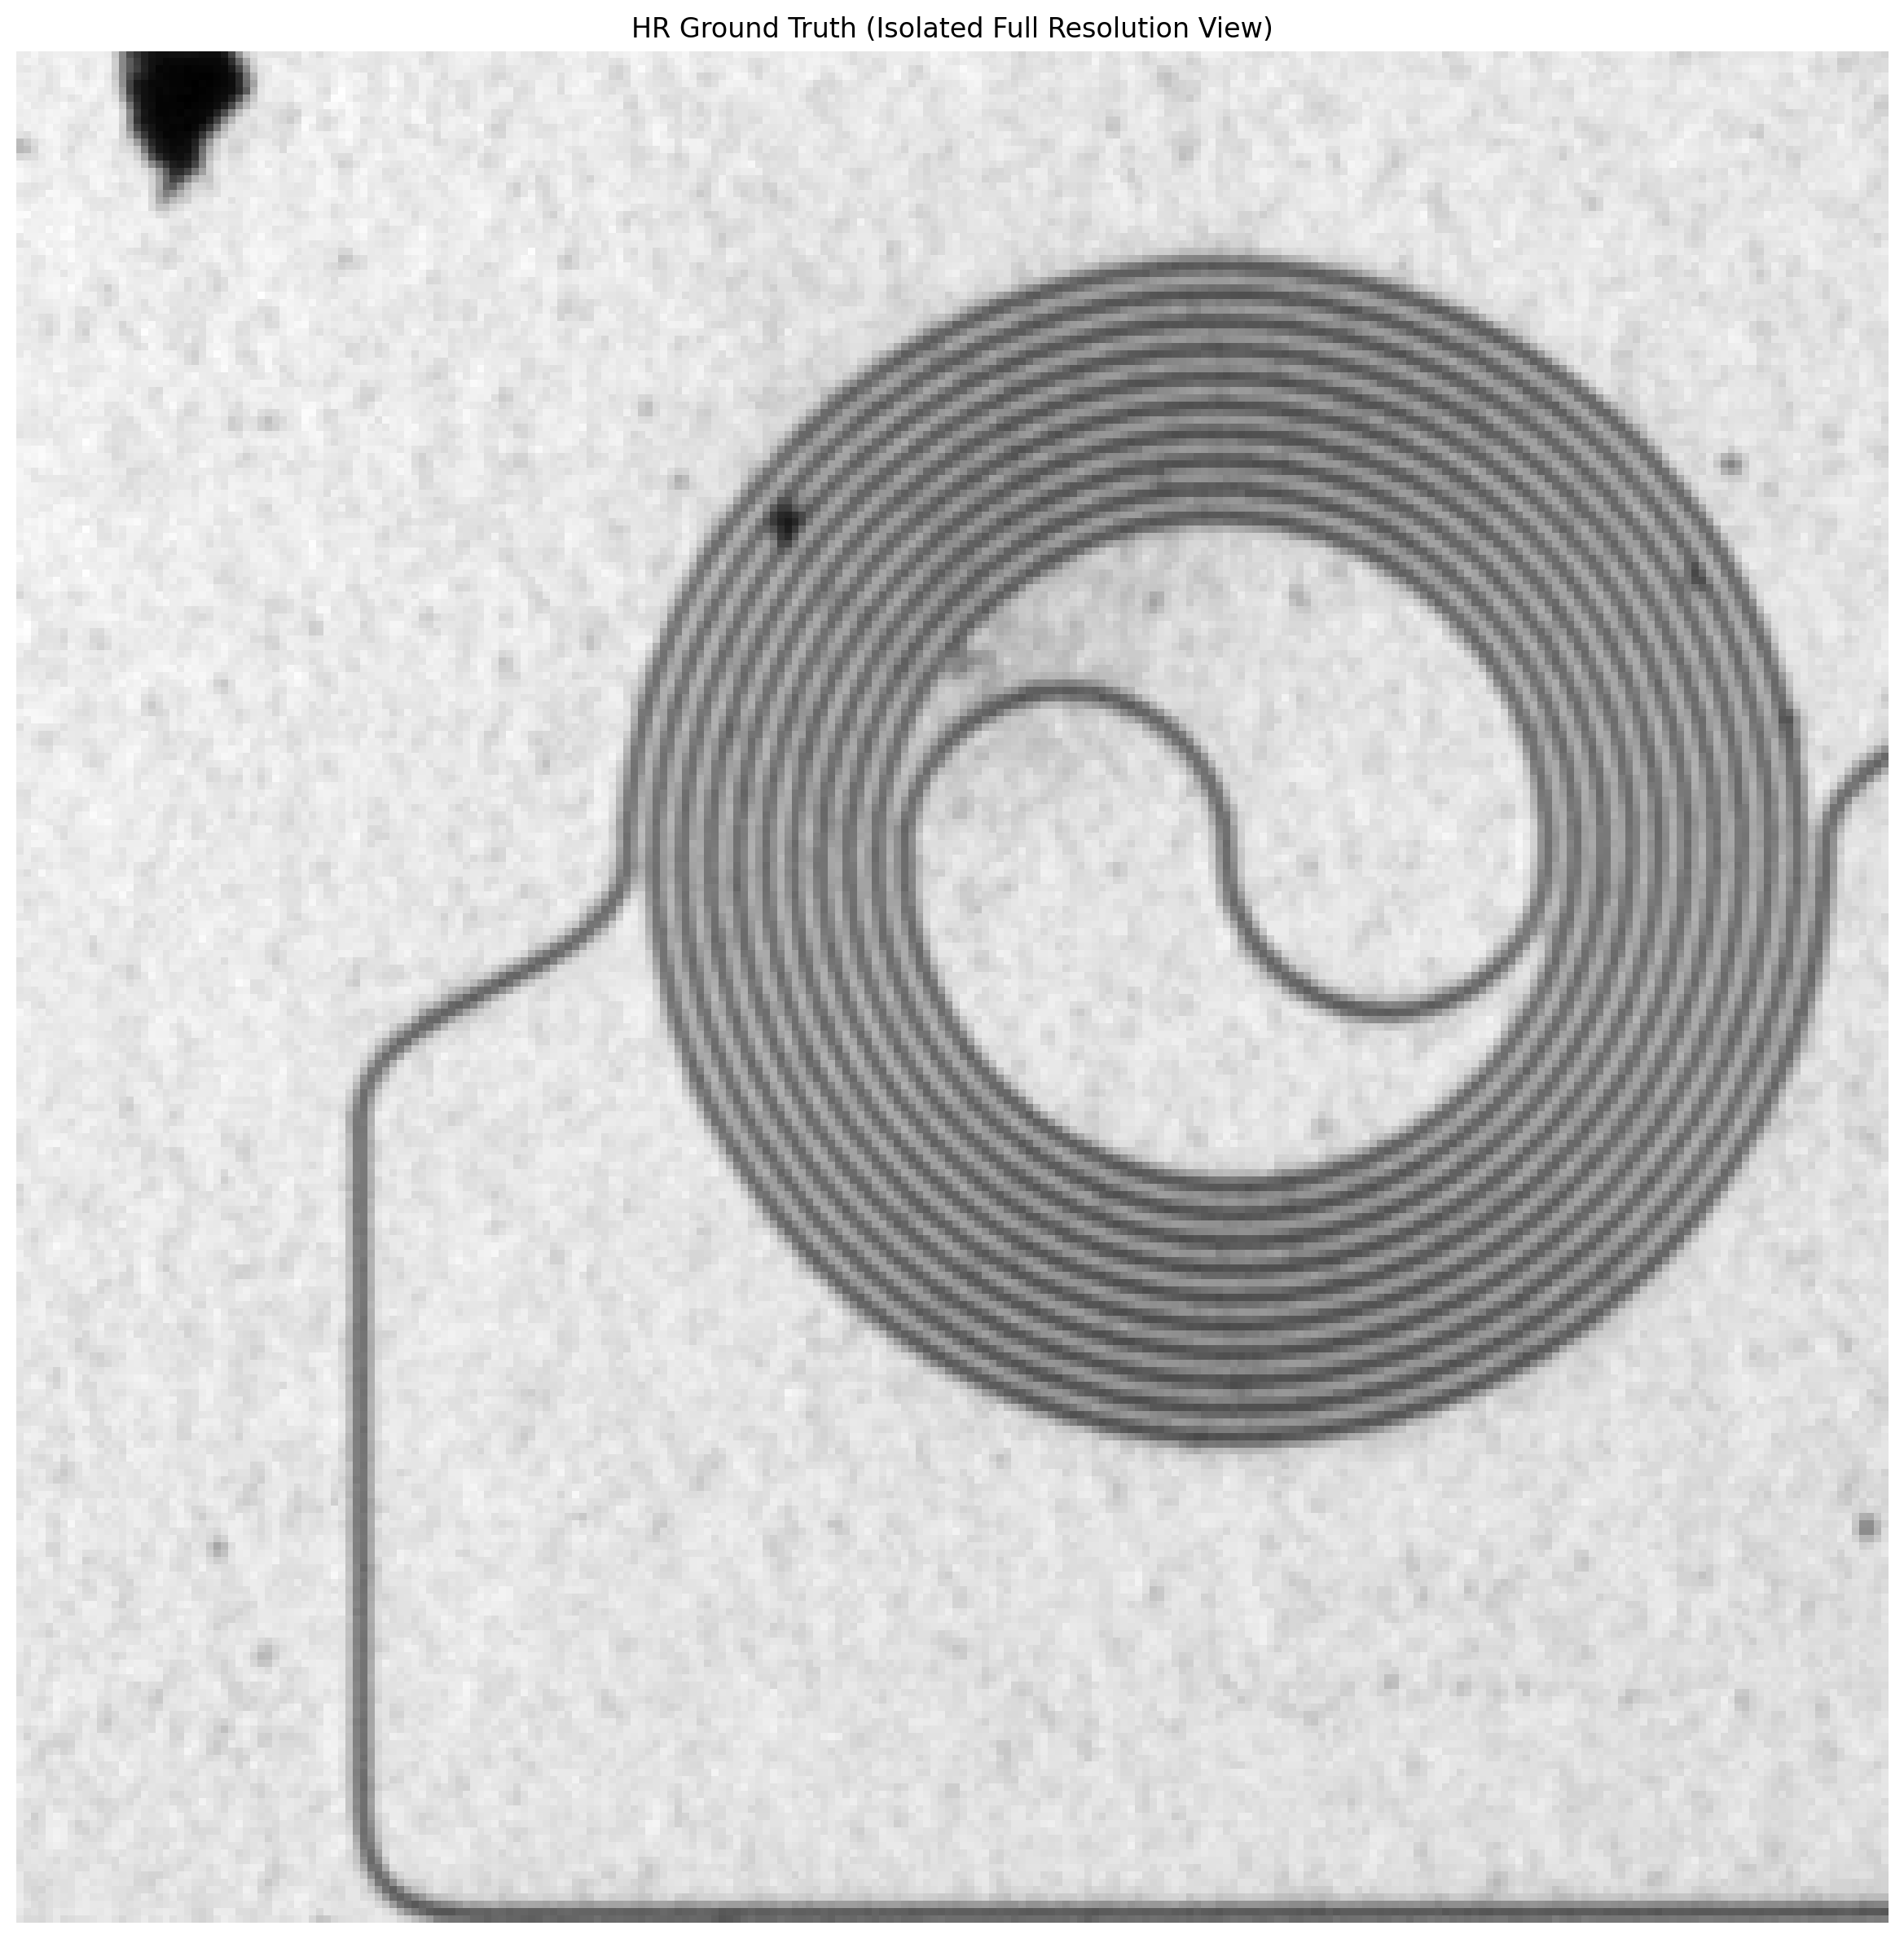

SR isolated view shape: (256, 256)
HR isolated view shape: (256, 256)


In [ ]:
if hr_true is not None:
    # 2x2 quick comparison view
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    # Top left: LR upsampled (nearest neighbor)
    axes[0, 0].imshow(lr_upsampled, cmap='gray')
    axes[0, 0].set_title('LR View (2x nearest-neighbor)')
    axes[0, 0].axis('off')
    
    # Top right: LR bicubic
    lr_bicubic = ndimage.zoom(lr_first, 2, order=3)
    axes[0, 1].imshow(lr_bicubic, cmap='gray')
    bicubic_title = f'LR (2x bicubic)\nPSNR = {bicubic_metrics["psnr"]:.2f} dB' if bicubic_metrics['valid'] else 'LR (2x bicubic)'
    axes[0, 1].set_title(bicubic_title)
    axes[0, 1].axis('off')
    
    # Bottom left: HighRes-Net SR
    axes[1, 0].imshow(sr, cmap='gray')
    sr_title = f'HighRes-Net SR Output\nPSNR = {nn_metrics["psnr"]:.2f} dB' if nn_metrics['valid'] else 'HighRes-Net SR Output'
    axes[1, 0].set_title(sr_title)
    axes[1, 0].axis('off')
    if not weight_status.get('has_weights', False):
        axes[1, 0].text(0.5, 0.02, '(Random weights)', 
                        ha='center', transform=axes[1, 0].transAxes,
                        fontsize=10, color='red', weight='bold')
    
    # Bottom right: HR ground truth
    axes[1, 1].imshow(hr_true, cmap='gray')
    axes[1, 1].set_title('HR Ground Truth')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

    # Full-resolution isolated SR view
    plt.figure(figsize=(12, 12), dpi=200)
    plt.imshow(sr, cmap='gray')
    plt.title('HighRes-Net SR (Isolated Full Resolution View)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Full-resolution isolated HR ground truth view
    plt.figure(figsize=(12, 12), dpi=200)
    plt.imshow(hr_true, cmap='gray')
    plt.title('HR Ground Truth (Isolated Full Resolution View)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"SR isolated view shape: {sr.shape}")
    print(f"HR isolated view shape: {hr_true.shape}")
else:
    print("Cannot visualize: HR not loaded")